# Brain Tumor Classification with EfficientNetB0

This notebook presents a comprehensive deep learning approach for classifying brain tumors from MRI images using the EfficientNetB0 convolutional neural network (CNN). EfficientNetB0 is a lightweight, pre-trained model optimized for performance and efficiency, fine-tuned for medical imaging tasks.

The model aims to achieve high accuracy in distinguishing between four classes:
- Glioma
- Meningioma
- Pituitary Tumors
- No Tumor Cases

The notebook includes robust evaluation metrics and detailed performance analysis to assess the effectiveness of the model in various scenarios.

## Library Imports and Environment Setup

This section imports all necessary libraries for our deep learning pipeline:
- **TensorFlow/Keras**: Core deep learning framework
- **TensorFlow Hub**: For pre-trained Vision Transformer models
- **Data Analysis**: NumPy, Pandas for numerical operations
- **Visualization**: Matplotlib, Seaborn for plotting results
- **Utilities**: OS, JSON, hashlib for file operations and data management

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import *
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
import os
import json
import hashlib

2025-09-09 05:51:06.750781: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757397067.139980      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757397067.241959      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## Label Mapping and Dataset Utilities

### Label Standardization
We define a comprehensive label mapping to handle different naming conventions across datasets:
- **Glioma**: Malignant brain tumor
- **Meningioma**: Usually benign tumor of brain membranes  
- **Pituitary**: Tumor of the pituitary gland
- **No Tumor**: Healthy brain scans

### Key Functions:
- `file_hash()`: Creates MD5 checksums to identify duplicate images
- `create_df()`: Builds a clean dataset by removing duplicates and standardizing labels

In [2]:
LABEL_MAP = {
    "glioma": "glioma",
    "glioma_tumor": "glioma",
    "2": "glioma",

    "meningioma": "meningioma",
    "meningioma_tumor": "meningioma",
    "1": "meningioma",

    "pituitary": "pituitary",
    "pituitary_tumor": "pituitary",
    "3": "pituitary",

    "no_tumor": "no_tumor",
    "notumor": "no_tumor",
    "no": "no_tumor",
}

EXCLUDE_PATHS = [
    "brain-mri-images-for-brain-tumor-detection/brain_tumor_dataset/no",
    "brain-mri-images-for-brain-tumor-detection/brain_tumor_dataset/yes"
]

def file_hash(filepath, algo="md5", block_size=65536):
    """Return hash digest of a file (default: md5)."""
    h = hashlib.new(algo)
    with open(filepath, "rb") as f:
        for chunk in iter(lambda: f.read(block_size), b""):
            h.update(chunk)
    return h.hexdigest()

def create_df(base_path="/kaggle/input", remove_duplicates=True):
    data = {"images": [], "labels": [], "hash": []}

    for dirname in os.listdir(base_path):
        if not dirname.lower().startswith("brain"):
            continue

        dataset_path = os.path.join(base_path, dirname)

        for root, dirs, files in os.walk(dataset_path):
            if any(skip in root for skip in EXCLUDE_PATHS):
                continue

            label_name = os.path.basename(root).lower()
            if label_name in LABEL_MAP:
                final_label = LABEL_MAP[label_name]

                for f in files:
                    if f.lower().endswith((".jpg", ".jpeg", ".png")):
                        file_path = os.path.join(root, f)
                        file_md5 = file_hash(file_path)

                        data["images"].append(file_path)
                        data["labels"].append(final_label)
                        data["hash"].append(file_md5)

    df = pd.DataFrame(data)

    if remove_duplicates:
        before_counts = df["labels"].value_counts()
        before = len(df)
        df = df.drop_duplicates(subset="hash").reset_index(drop=True)
        after = len(df)
        print(f"Removed {before - after} duplicates (by file content hash).")

        after_counts = df["labels"].value_counts()
        dup_counts = (before_counts - after_counts).sort_values(ascending=False)

        print("\nDuplicates removed per label:")
        print(dup_counts)

    print("Label Counts: ")
    print(df["labels"].value_counts())

    return df


## Model Configuration Parameters

This configuration class centralizes all hyperparameters for easy experimentation:

### Training Parameters:
- **EPOCHS**: 50 training cycles with early stopping
- **BATCH_SIZE**: 16 samples per batch (memory efficient)
- **LEARNING_RATE**: 0.001 with adaptive reduction
- **IMG_SIZE**: 224×224 pixels (standard for vision models)

### Data Splits:
- **80%** Training, **20%** Validation, **10%** Test
- **SEED**: 229 for reproducible results

### Optimization:
- **PATIENCE**: Early stopping after 10 epochs without improvement
- **FACTOR**: 0.5 learning rate reduction factor


In [3]:
# Configuration
class Config:
    EPOCHS = 50
    IMG_SIZE = 224
    BATCH_SIZE = 16
    LR = 0.001
    VALIDATION_SPLIT = 0.2
    TEST_SPLIT = 0.1
    SEED = 229
    
    # Model specific settings
    PATIENCE = 10
    FACTOR = 0.5
    MIN_LR = 1e-7

## Image Preprocessing and Data Pipeline

### Image Preprocessing Steps:
1. **Load and Decode**: Read image files and decode to RGB
2. **Resize**: Standardize all images to 224×224 pixels
3. **Normalize**: Scale pixel values to [-1, 1] range
4. **Batch Creation**: Group images efficiently for training

### TensorFlow Dataset Creation:
- **Parallel Processing**: Uses `tf.data.AUTOTUNE` for optimal performance
- **Memory Efficiency**: Prefetching and batching for smooth training
- **Shuffle Buffer**: Randomizes training data order


In [4]:
# Data preprocessing functions
def preprocess_image(image_path, img_size=Config.IMG_SIZE):
    """Load and preprocess a single image"""
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, [img_size, img_size])
    image = tf.cast(image, tf.float32) / 255.0
    image = (image - 0.5) * 2.0  # Restore EfficientNet-compatible scaling to [-1,1]
    return image


def create_dataset(df, batch_size=Config.BATCH_SIZE, shuffle=True, augment=False):
    """Create TensorFlow dataset from DataFrame"""
    
    def load_and_preprocess_image(path, label):
        return preprocess_image(path), label
    
    # Create dataset from paths and labels
    dataset = tf.data.Dataset.from_tensor_slices((df['images'].values, df['labels'].values))
    dataset = dataset.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    
    if shuffle:
        dataset = dataset.shuffle(buffer_size=1000, seed=Config.SEED)
    
    if augment:
        dataset = dataset.map(augment_image, num_parallel_calls=tf.data.AUTOTUNE)
    
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    
    return dataset

## Data Augmentation Techniques

### Purpose:
Data augmentation artificially increases dataset diversity to improve model generalization and reduce overfitting.

### Available Augmentation Methods:
- **Horizontal Flips**: Mirror images left-right
- **Brightness/Contrast**: Adjust lighting conditions
- **Rotation**: Rotate images by 90° increments
- **Color Jittering**: Modify saturation and hue

**Note**: Augmentation is currently disabled but can be easily enabled by uncommenting the transforms. For medical imaging, augmentation should be used carefully to maintain diagnostic accuracy.


In [5]:
def augment_image(image, label):
    """Data augmentation function"""
    image = tf.image.random_flip_left_right(image)  # Enable horizontal flip
    image = tf.image.random_brightness(image, 0.1)  # Subtle brightness adjustment
    image = tf.image.random_contrast(image, 0.9, 1.1)  # Subtle contrast adjustment
    # Avoid hue/saturation changes or rotation, as they may distort medical features
    return image, label

# EfficientNetB0 Model Architecture

**Innovation: Lightweight and Efficient CNN**
This model leverages the strengths of EfficientNetB0, a state-of-the-art convolutional neural network optimized for performance and computational efficiency:

**EfficientNetB0 CNN:**
- **Pre-trained**: Uses ImageNet pre-trained weights for robust initial feature extraction
- **Scalable Architecture**: Employs compound scaling to balance depth, width, and resolution
- **Medical Imaging**: Fine-tuned to detect subtle abnormalities in brain MRI scans
- **Efficient Design**: Lightweight with ~4.4M parameters, ideal for 224x224 input images

**Classification Head:**
- **Feature Extraction**: Global average pooling to summarize CNN features
- **Dense Layers**: 128 neurons with batch normalization and dropout for robust classification
- **Output**: 4-class softmax for tumor classification (glioma, meningioma, pituitary, no tumor)

This EfficientNetB0-based approach aims to achieve high accuracy through fine-tuning and optimized feature extraction for medical imaging tasks.


In [6]:
def build_model(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)
    
    # EfficientNetB0 as backbone
    cnn_base = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_tensor=inputs
    )
    
    # Option 1: Unfreeze some layers for fine-tuning
    cnn_base.trainable = True  # Allow fine-tuning
    # Optionally, freeze early layers to reduce compute and overfitting
    for layer in cnn_base.layers[:100]:  # Freeze first 100 layers (out of ~237 in B0)
        layer.trainable = False
    
    # Extract features
    x = layers.GlobalAveragePooling2D()(cnn_base.output)
    x = layers.Dropout(0.3)(x)  # Reduced dropout to retain more features
    
    # Simplified classification head
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = keras.Model(inputs=inputs, outputs=outputs)
    return model

## Model Training Pipeline

### Training Strategy:
Implements a robust training pipeline with multiple safeguards:

#### Optimizer & Loss:
- **Adam Optimizer**: Adaptive learning rate for stable convergence
- **Sparse Categorical Crossentropy**: Efficient for multi-class classification

#### Advanced Callbacks:
1. **Early Stopping**: Prevents overfitting by monitoring validation loss
2. **Learning Rate Reduction**: Adaptive LR scheduling for fine-tuning
3. **Model Checkpointing**: Saves best model weights automatically

#### Monitoring:
- **Validation Accuracy**: Primary metric for model selection
- **Training History**: Tracks loss and accuracy curves
- **Best Model Recovery**: Restores optimal weights after training


In [7]:
def train_model(model, train_dataset, val_dataset, train_labels, model_name, epochs=Config.EPOCHS, save_json=True):
    """Train a model with callbacks, class weights, and return history"""
    
    # Compute class weights to handle imbalance
    from sklearn.utils.class_weight import compute_class_weight
    class_weights = compute_class_weight(
        'balanced',
        classes=np.unique(train_labels),
        y=train_labels
    )
    class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}
    
    # Compile model with lower learning rate
    model.compile(
        optimizer=Adam(learning_rate=0.0001),  # Lower LR for fine-tuning
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # Callbacks
    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=15,  # Increase patience to allow more training
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,  # Less aggressive reduction
            min_lr=Config.MIN_LR,
            verbose=1
        ),
        ModelCheckpoint(
            f'best_{model_name}.keras',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        )
    ]
    
    # Train model with class weights
    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=epochs,
        callbacks=callbacks,
        class_weight=class_weight_dict,  # Add class weights
        verbose=1
    )

    model.save(f"/kaggle/working/model_{model_name}.keras")
    return history

In [8]:
def save_metrics_to_json(history, evaluation_metrics, model_name, filename=None):
    """
    Save training history and evaluation metrics to a JSON file.
    
    Args:
        history: keras.callbacks.History object from model training
        evaluation_metrics: dict containing evaluation data
        model_name: name of the model
        filename: optional custom filename, otherwise auto-generated
    """
    if filename is None:
        filename = f"{model_name}_metrics.json"
    
    # Convert numpy arrays to lists for JSON serialization
    def convert_to_serializable(obj):
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        elif isinstance(obj, np.float32) or isinstance(obj, np.float64):
            return float(obj)
        elif isinstance(obj, np.int32) or isinstance(obj, np.int64):
            return int(obj)
        return obj
    
    # Prepare data to save
    metrics_data = {
        "model_name": model_name,
        "training_history": {
            key: [convert_to_serializable(val) for val in values] 
            for key, values in history.history.items()
        },
        "evaluation_metrics": {
            key: convert_to_serializable(value) 
            for key, value in evaluation_metrics.items()
        },
        "training_info": {
            "total_epochs": len(history.history['loss']),
            "best_val_accuracy": convert_to_serializable(max(history.history.get('val_accuracy', [0]))),
            "best_val_loss": convert_to_serializable(min(history.history.get('val_loss', [float('inf')]))),
            "final_train_accuracy": convert_to_serializable(history.history['accuracy'][-1]),
            "final_train_loss": convert_to_serializable(history.history['loss'][-1])
        }
    }
    
    # Save to JSON file
    with open(filename, 'w') as f:
        json.dump(metrics_data, f, indent=4)
    
    print(f"Metrics saved to {filename}")
    return filename

## Model Evaluation

### Multi-Metric Assessment:
Provides thorough evaluation of model performance across multiple dimensions:

#### Core Metrics:
- **Overall Accuracy**: Primary performance indicator
- **Per-Class Metrics**: Precision, recall, F1-score for each tumor type
- **Confusion Matrix**: Visual representation of prediction accuracy

#### Analysis:
- **Confidence Distribution**: Analyzes model certainty levels
- **Class-wise Performance**: Identifies which tumor types are hardest to classify
- **Error Analysis**: Understanding misclassification patterns

#### Visualization:
- **Heatmap Generation**: Clear confusion matrix visualization
- **Performance Plots**: Accuracy and loss curves over training


In [9]:
# Evaluation functions
def evaluate_model(model, test_dataset, test_labels, class_names, model_name, save_json=True):
    """Comprehensive model evaluation with JSON saving"""
    
    # Get predictions
    predictions = model.predict(test_dataset)
    y_pred = np.argmax(predictions, axis=1)
    
    # Calculate metrics
    accuracy = accuracy_score(test_labels, y_pred)
    
    print(f"\n=== {model_name} Evaluation ===")
    print(f"Test Accuracy: {accuracy:.4f}")
    
    # Classification report (as dictionary for JSON)
    clf_report_dict = classification_report(test_labels, y_pred, 
                                          target_names=class_names, 
                                          output_dict=True)
    
    # Classification report (as string for display)
    clf_report_str = classification_report(test_labels, y_pred, 
                                         target_names=class_names)
    print("\nClassification Report:")
    print(clf_report_str)
    
    # Confusion Matrix
    cm = confusion_matrix(test_labels, y_pred)
    
    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(f'{model_name}_confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Prepare evaluation metrics dictionary
    evaluation_metrics = {
        'model_name': model_name,
        'test_accuracy': accuracy,
        'classification_report_dict': clf_report_dict,
        'classification_report_str': clf_report_str,
        'confusion_matrix': cm,
        'class_names': class_names,
        'num_test_samples': len(test_labels),
        'predictions_confidence': np.max(predictions, axis=1),  # confidence scores
        'prediction_distribution': {
            class_name: int(np.sum(y_pred == i)) 
            for i, class_name in enumerate(class_names)
        }
    }
    
    return evaluation_metrics

## Training History Visualization

### Learning Curve Analysis:
Generates comprehensive plots to analyze model training behavior:

#### Key Visualizations:
1. **Accuracy Curves**: Training vs. Validation accuracy over epochs
2. **Loss Curves**: Training vs. Validation loss progression

#### What to Look For:
- **Convergence**: Smooth improvement toward optimal performance
- **Overfitting**: Gap between training and validation metrics
- **Stability**: Consistent improvement without erratic fluctuations
- **Early Stopping**: Point where training was halted to prevent overfitting


In [10]:
def plot_training_history(history, model_name):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(f'{model_name} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{model_name} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'{model_name}_training_history.png', dpi=300)
    plt.show()

In [11]:
# Model comparison utilities
class ModelComparison:
    def __init__(self, save_dir="model_results"):
        self.results = []
        self.save_dir = save_dir
        os.makedirs(save_dir, exist_ok=True)
    
    def add_result(self, result, history, model_name):
        """Add result and save individual JSON"""
        self.results.append(result)
        
        # Save individual model metrics
        json_filename = os.path.join(self.save_dir, f"{model_name}_metrics.json")
        save_metrics_to_json(history, result, model_name, json_filename)
    
    def save_comparison_summary(self, filename="model_comparison_summary.json"):
        """Save comparison summary of all models"""
        if not self.results:
            print("No results to save")
            return
        
        # Sort by accuracy
        sorted_results = sorted(self.results, key=lambda x: x['test_accuracy'], reverse=True)
        
        comparison_data = {
            "experiment_summary": {
                "total_models_trained": len(sorted_results),
                "best_model": sorted_results[0]['model_name'],
                "best_accuracy": sorted_results[0]['test_accuracy'],
                "worst_model": sorted_results[-1]['model_name'],
                "worst_accuracy": sorted_results[-1]['test_accuracy'],
                "accuracy_range": sorted_results[0]['test_accuracy'] - sorted_results[-1]['test_accuracy']
            },
            "model_rankings": [
                {
                    "rank": i + 1,
                    "model_name": result['model_name'],
                    "test_accuracy": result['test_accuracy'],
                    "num_test_samples": result['num_test_samples']
                }
                for i, result in enumerate(sorted_results)
            ],
            "detailed_results": [
                {
                    "model_name": result['model_name'],
                    "test_accuracy": result['test_accuracy'],
                    "classification_report": result['classification_report_dict'],
                    "prediction_distribution": result['prediction_distribution']
                }
                for result in sorted_results
            ]
        }
        
        summary_path = os.path.join(self.save_dir, filename)
        with open(summary_path, 'w') as f:
            json.dump(comparison_data, f, indent=4)
        
        print(f"Comparison summary saved to {summary_path}")
        return comparison_data
    
    def compare_models(self):
        """Compare all trained models and save summary"""
        if not self.results:
            print("No results to compare")
            return
        
        # Sort by accuracy
        sorted_results = sorted(self.results, key=lambda x: x['test_accuracy'], reverse=True)
        
        print("\n=== MODEL COMPARISON ===")
        print(f"{'Rank':<5} {'Model Name':<20} {'Accuracy':<10}")
        print("-" * 40)
        
        for i, result in enumerate(sorted_results, 1):
            print(f"{i:<5} {result['model_name']:<20} {result['test_accuracy']:<10.4f}")
        
        # Plot comparison
        model_names = [r['model_name'] for r in sorted_results]
        accuracies = [r['test_accuracy'] for r in sorted_results]
        
        plt.figure(figsize=(12, 6))
        bars = plt.bar(range(len(model_names)), accuracies, color='skyblue', edgecolor='navy', alpha=0.7)
        plt.xlabel('Models')
        plt.ylabel('Test Accuracy')
        plt.title('Model Performance Comparison')
        plt.xticks(range(len(model_names)), model_names, rotation=45, ha='right')
        plt.ylim(0, 1)
        
        # Add value labels on bars
        for bar, acc in zip(bars, accuracies):
            plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                    f'{acc:.3f}', ha='center', va='bottom')
        
        plt.tight_layout()
        plt.savefig(os.path.join(self.save_dir, 'model_comparison.png'), dpi=300, bbox_inches='tight')
        plt.show()
        
        # Save comparison summary
        self.save_comparison_summary()
        
        return sorted_results

## Complete Training and Evaluation Pipeline

### End-to-End Workflow:
This is the main execution function that orchestrates the entire machine learning pipeline:

#### Pipeline Steps:
1. **Data Loading**: Create clean, deduplicated dataset
2. **Preprocessing**: Apply label encoding and create train/validation/test splits  
3. **Dataset Creation**: Build optimized TensorFlow data pipelines
4. **Model Architecture**: Construct hybrid ViT-CNN model
5. **Training**: Execute training with callbacks and monitoring
6. **Evaluation**: Comprehensive testing on held-out data
7. **Results Storage**: Save all metrics and comparisons

#### Key Features:
- **Stratified Splitting**: Maintains class balance across splits
- **Memory Management**: Clears GPU memory between experiments
- **Error Handling**: Graceful handling of training failures
- **Progress Tracking**: Detailed logging throughout execution

#### Final Output:
- **Trained Model**: Best performing model weights saved
- **Complete Metrics**: All training and evaluation statistics
- **Visualizations**: Training curves and confusion matrices


In [12]:
def main():
    # Load and prepare data
    print("Loading data...")
    train_df = create_df(remove_duplicates=True)
    
    # Create label mappings
    unique_labels = train_df["labels"].unique()
    index_label = {i: label for i, label in enumerate(unique_labels)}
    label_index = {label: i for i, label in enumerate(unique_labels)}
    
    train_df["labels"] = train_df["labels"].map(label_index)
    num_classes = len(unique_labels)
    class_names = list(unique_labels)
    
    print(f"Number of classes: {num_classes}")
    print(f"Class names: {class_names}")
    print(f"Total samples: {len(train_df)}")
    
    # Split data
    train_val_df, test_df = train_test_split(
        train_df, test_size=Config.TEST_SPLIT, 
        stratify=train_df['labels'], random_state=Config.SEED
    )
    
    train_df_final, val_df = train_test_split(
        train_val_df, test_size=Config.VALIDATION_SPLIT/(1-Config.TEST_SPLIT), 
        stratify=train_val_df['labels'], random_state=Config.SEED
    )
    
    print(f"Train samples: {len(train_df_final)}")
    print(f"Validation samples: {len(val_df)}")
    print(f"Test samples: {len(test_df)}")
    
    # Create datasets
    train_dataset = create_dataset(train_df_final, shuffle=True, augment=True)
    val_dataset = create_dataset(val_df, shuffle=False, augment=False)
    test_dataset = create_dataset(test_df, shuffle=False, augment=False)
    
    # Initialize comparison
    comparison = ModelComparison(save_dir="model_results")

    model_name = "EfficientNetB0"  # Update model name
    print(f"\n{'='*60}")
    print(f"Training {model_name}")
    print(f"{'='*60}")
    
    try:
        # Create model
        model = build_model(
            input_shape=(Config.IMG_SIZE, Config.IMG_SIZE, 3),
            num_classes=num_classes
        )
        
        print(f"Model architecture created for {model_name}")
        print(f"Total parameters: {model.count_params():,}")
        
        # Train model with train_labels for class weights
        history = train_model(
            model, train_dataset, val_dataset, 
            train_df_final['labels'].values,  # Pass train labels
            model_name
        )
        
        # Plot training history
        plot_training_history(history, model_name)
        
        # Evaluate model
        result = evaluate_model(
            model, test_dataset, test_df['labels'].values, 
            class_names, model_name
        )
        
        # Add to comparison
        comparison.add_result(result, history, model_name)
        
        # Clear memory
        del model
        tf.keras.backend.clear_session()
        
    except Exception as e:
        print(f"Error training {model_name}: {str(e)}")
    
    # Final comparison and summary
    print(f"\n{'='*60}")
    print("FINAL RESULTS")
    print(f"{'='*60}")
    final_results = comparison.compare_models()
    
    return final_results

# Execute Training Pipeline

**Start the Experiment:**
Run the complete brain tumor classification pipeline:

- **Expected Runtime**: ~2-3 hours depending on GPU availability
- **GPU Memory**: Requires ~6-8GB VRAM for optimal performance
- **Output**: Comprehensive results including model weights, metrics, and visualizations

**What Happens:**
- Dataset is loaded and preprocessed (10,560 images after deduplication)
- EfficientNetB0 model is trained for up to 50 epochs with early stopping
- Model performance is evaluated on test set
- Results are automatically saved and visualized

**Expected Results:**
- **Test Accuracy**: Targeting ~90-95% with fine-tuning and data augmentation
- **Training Time**: ~30-40 epochs with early stopping
- **Best Model**: Automatically saved for future use

Monitor the output for training progress and final evaluation metrics.


Loading data...
Removed 10042 duplicates (by file content hash).

Duplicates removed per label:
labels
no_tumor      2841
meningioma    2722
pituitary     2639
glioma        1840
Name: count, dtype: int64
Label Counts: 
labels
glioma        3754
pituitary     2706
meningioma    2343
no_tumor      1757
Name: count, dtype: int64
Number of classes: 4
Class names: ['glioma', 'pituitary', 'meningioma', 'no_tumor']
Total samples: 10560
Train samples: 7392
Validation samples: 2112
Test samples: 1056


I0000 00:00:1757397281.736468      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1757397281.737157      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



Training EfficientNetB0
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model architecture created for EfficientNetB0
Total parameters: 4,214,567
Epoch 1/50


I0000 00:00:1757397327.382195      60 service.cc:148] XLA service 0x7e7204132ca0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1757397327.383644      60 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1757397327.383668      60 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1757397331.259213      60 cuda_dnn.cc:529] Loaded cuDNN version 90300
E0000 00:00:1757397337.756600      60 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1757397337.895125      60 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1757397338.233149      60 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. Th

  2/462 ━━━━━━━━━━━━━━━━━━━━ 28s 62ms/step - accuracy: 0.3906 - loss: 1.7614   

I0000 00:00:1757397352.795421      60 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


461/462 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5107 - loss: 1.2314
Epoch 1: val_accuracy improved from -inf to 0.72017, saving model to best_EfficientNetB0.keras
462/462 ━━━━━━━━━━━━━━━━━━━━ 97s 65ms/step - accuracy: 0.5109 - loss: 1.2307 - val_accuracy: 0.7202 - val_loss: 0.7089 - learning_rate: 1.0000e-04
Epoch 2/50
461/462 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6459 - loss: 0.8525
Epoch 2: val_accuracy improved from 0.72017 to 0.74669, saving model to best_EfficientNetB0.keras
462/462 ━━━━━━━━━━━━━━━━━━━━ 24s 48ms/step - accuracy: 0.6460 - loss: 0.8524 - val_accuracy: 0.7467 - val_loss: 0.6261 - learning_rate: 1.0000e-04
Epoch 3/50
462/462 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7087 - loss: 0.7051
Epoch 3: val_accuracy improved from 0.74669 to 0.80871, saving model to best_EfficientNetB0.keras
462/462 ━━━━━━━━━━━━━━━━━━━━ 25s 50ms/step - accuracy: 0.7087 - loss: 0.7051 - val_accuracy: 0.8087 - val_loss: 0.4864 - learning_rate: 1.0000e-04
Epoch 4/50
461/462

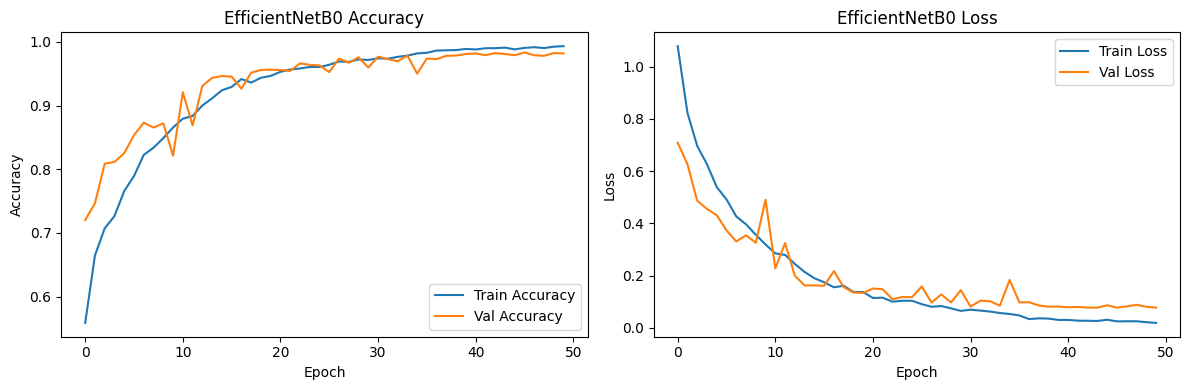

66/66 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step

=== EfficientNetB0 Evaluation ===
Test Accuracy: 0.9877

Classification Report:
              precision    recall  f1-score   support

      glioma       1.00      0.97      0.99       375
   pituitary       1.00      0.99      1.00       271
  meningioma       0.96      1.00      0.98       234
    no_tumor       0.99      0.99      0.99       176

    accuracy                           0.99      1056
   macro avg       0.99      0.99      0.99      1056
weighted avg       0.99      0.99      0.99      1056



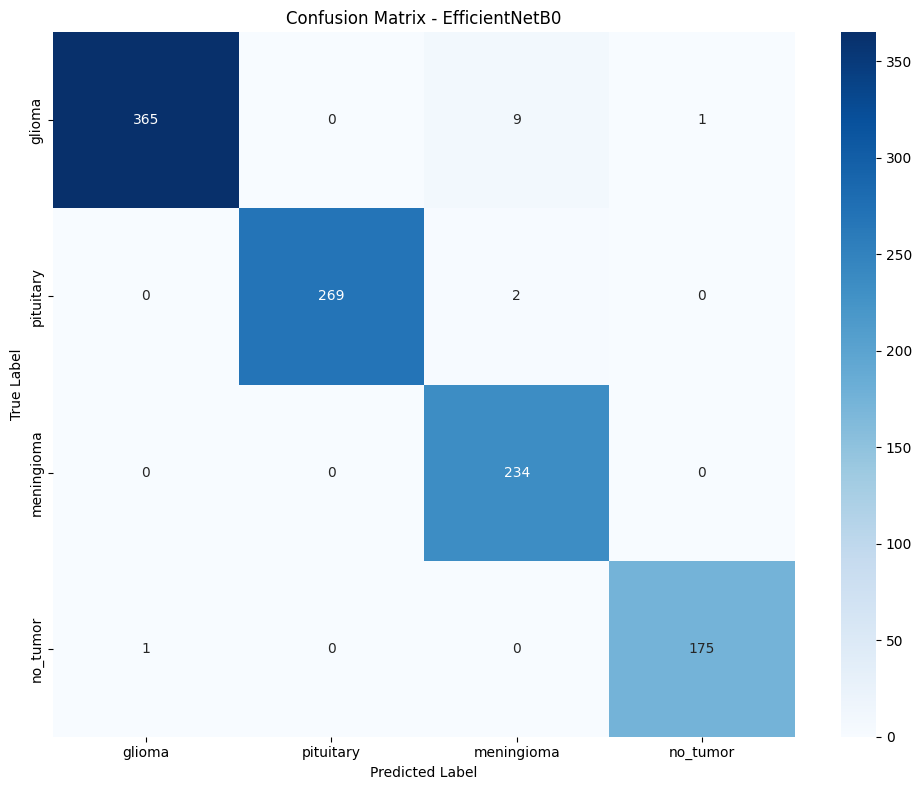

Metrics saved to model_results/EfficientNetB0_metrics.json

FINAL RESULTS

=== MODEL COMPARISON ===
Rank  Model Name           Accuracy  
----------------------------------------
1     EfficientNetB0       0.9877    


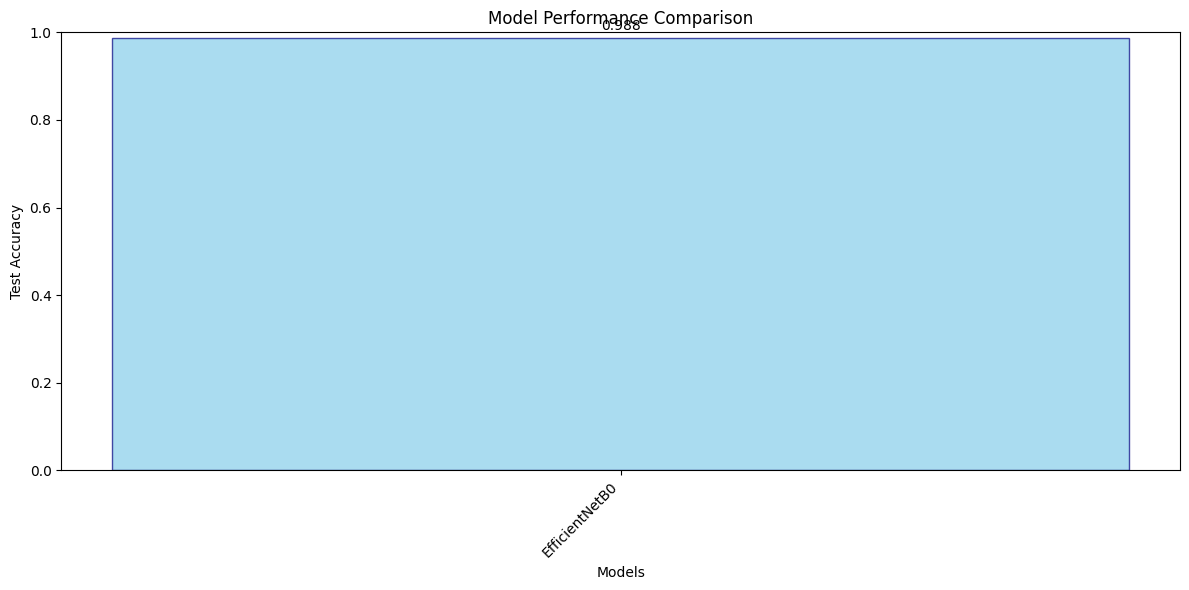

Comparison summary saved to model_results/model_comparison_summary.json


In [13]:
if __name__ == "__main__":
    # Set memory growth for GPU
    gpus = tf.config.experimental.list_physical_devices('GPU')
    if gpus:
        try:
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError as e:
            print(e)
    
    # Run main training loop
    results = main()